# Phase drift in PyCBC's CPU chi-square calculation

PyCBC tests a gravitational-wave candidate's consistency across frequency bins. At a selected sample index $t$, its CPU routine calculates
\[
q_b(t)=\sum_{k\in b}c_k e^{2\pi i kt/N},\qquad
S=\sum_b|q_b|^2,\qquad \chi^2=(pS-|z|^2)A^2.
\]
Here $c_k$ is the correlation spectrum, $N$ its length, $p$ the bin count, $z$ the unnormalized SNR and $A$ its normalization. The routine uses repeated complex multiplications to advance phase; it performs **no FFT**.

This controlled example asks whether those rotations preserve unit power when the input is complex64. It compares the actual compiled [upstream source](kernels/upstream.pyx) and [double-precision implementation](kernels/arithmetic.pyx). The patch promotes phase, products and sums together to double precision, retaining complex64 inputs and float32 outputs.

## Run

Run beside `cpu_chisq_review.py` with PyCBC, NumPy, Matplotlib, Cython and a C++ compiler installed. **Restart Kernel and Run All**; the helper builds and caches archived kernels with identical flags.

In [1]:
import warnings
warnings.filterwarnings("ignore", message="Wswiglal-redir-stdio:")

import sys
from unittest.mock import patch
import numpy as np
import matplotlib.pyplot as plt
import pycbc.vetoes.chisq as public_chisq
from pycbc.scheme import CPUScheme
from pycbc.types import Array
from cpu_chisq_review import kernels, load_capture, plot_style

plot_style()
cpu = kernels(("upstream", "arithmetic"))
variants = ("upstream", "arithmetic")
labels = {"upstream": "Upstream", "arithmetic": "Double working precision"}
colors = {"upstream": "#245885", "arithmetic": "#B77818"}
capture = load_capture()
captured_width = int(np.max(np.diff(capture["bins"])))
print(f"Python {sys.version.split()[0]} | NumPy {np.__version__}")
print(f"Saved H1 widest bin: {captured_width:,} coefficients")
print("CPU source: gwastro/pycbc@454ee900e (2026-09-22 upstream snapshot)")

Compiling archived CPU kernels once; build log: /var/folders/l0/3dr1pyw15ln58b6xh74j_41w0000gn/T/pycbc-chisq-review-0bc733d79fbc5339/build.log


Python 3.13.7 | NumPy 2.3.5
Saved H1 widest bin: 373,308 coefficients
CPU source: gwastro/pycbc@454ee900e (2026-09-22 upstream snapshot)


## One nonzero coefficient: exact $S=1$

Hold $N=2^{20}$ and $t=100000$ fixed. Place a unit coefficient at the end of a bin of width $w$, with every other coefficient zero. The kernel must make $w-1$ rotations before reaching it. A second, equally wide bin is empty. Exact arithmetic gives $S=1$ and, with $p=2$, $|z|=A=1$, **$\chi^2=1$**.

There are no competing terms to accumulate. A phase-angle bias from truncated π cannot change this exact power; final-term and output rounding remain. The public wrapper is temporarily routed to each archived kernel, leaving its chi-square formula unchanged.

In [2]:
length, sample = 2**20, 100000
widths = np.unique(np.r_[4 ** np.arange(0, 10), captured_width, 2**19])
power = {name: [] for name in variants}
chisq = {name: [] for name in variants}
with CPUScheme():
    for width in widths:
        values = np.zeros(length, dtype=np.complex64)
        values[width - 1] = 1
        correlation = Array(values, copy=False)
        bins = [0, int(width), 2 * int(width)]
        for name in variants:
            result = cpu[name].shift_sum(correlation, [sample], bins)
            assert result.dtype == np.dtype(np.float32)
            power[name].append(float(result[0]))
            with patch.object(public_chisq, "shift_sum", cpu[name].shift_sum):
                result_chisq = public_chisq.power_chisq_at_points_from_precomputed(
                    correlation, np.ones(1, dtype=np.complex64), 1., bins, [sample])
            chisq[name].append(float(result_chisq[0]))
power = {name: np.asarray(values) for name, values in power.items()}
chisq = {name: np.asarray(values) for name, values in chisq.items()}
np.testing.assert_allclose(power["arithmetic"], 1, rtol=2e-7, atol=0)
np.testing.assert_allclose(chisq["arithmetic"], 1, rtol=4e-7, atol=0)

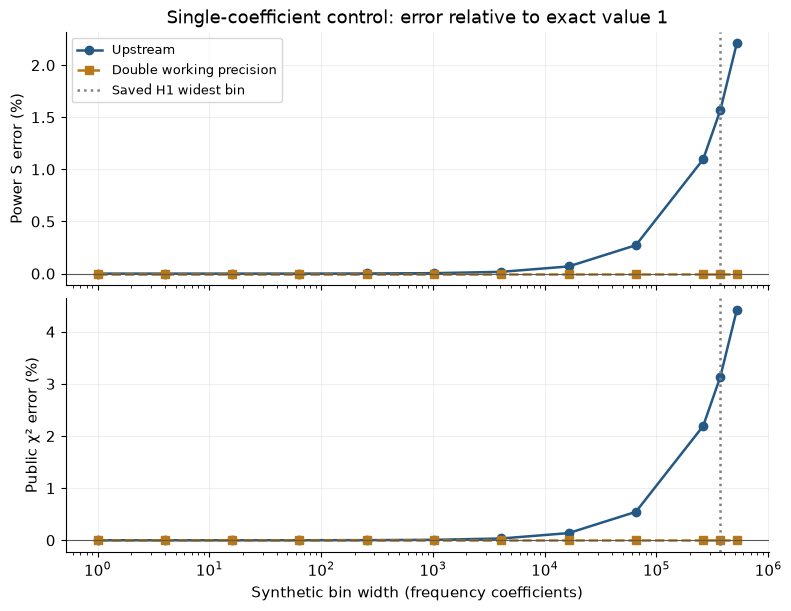

Synthetic control at width 373,308 (not a data replay):
Upstream: S = 1.015678883, χ² = 1.031357765
Double working precision: S = 1.000000000, χ² = 1.000000000


In [3]:
fig, axes = plt.subplots(2, 1, figsize=(7.8, 6), sharex=True,
                         constrained_layout=True)
for ax, results, ylabel in zip(axes, (power, chisq),
                               ("Power S error (%)", "Public χ² error (%)")):
    for name, marker, style in zip(variants, ("o", "s"), ("-", "--")):
        ax.plot(widths, 100 * (results[name] - 1), marker=marker,
                linestyle=style, color=colors[name], label=labels[name])
    ax.axhline(0, color="0.35", linewidth=0.8)
    ax.axvline(captured_width, color="0.5", linestyle=":",
               label="Saved H1 widest bin")
    ax.set(xscale="log", ylabel=ylabel)
axes[0].set_title("Single-coefficient control: error relative to exact value 1")
axes[0].legend(fontsize=9)
axes[1].set_xlabel("Synthetic bin width (frequency coefficients)")
plt.show()
j = int(np.flatnonzero(widths == captured_width)[0])
print(f"Synthetic control at width {captured_width:,} (not a data replay):")
for name in variants:
    print(f"{labels[name]}: S = {power[name][j]:.9f}, χ² = {chisq[name][j]:.9f}")

## Connection to detector data

The marked width, 373,308 coefficients, occurs in the [saved H1 calculation](../data/point-input-05.json). The plotted coefficients are synthetic: matching a bin width does not establish the error in that data. [Real-data replay](arithmetic_real_data.ipynb) compares the original and double-precision implementations on the captured input. [Accumulation controls](accumulation.ipynb) examine a separate mechanism; neither notebook assigns an individual share of the real-data discrepancy.